In [1]:
import random
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from keras.layers import Dense,InputLayer,Lambda,TextVectorization,Flatten,SimpleRNN,Reshape,Embedding,Input,Flatten,LSTM,Dropout
from keras.models import Sequential,Model
from keras.optimizers import Adam

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

2024-01-15 20:42:39.945353: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [3]:
samples = pd.read_csv('samples.csv')
samples = samples.sample(5000)

In [4]:
train, test = train_test_split(samples,test_size=.2,random_state=seed)
train, val = train_test_split(train,test_size=.2,random_state=seed)

In [5]:
max_tokens = 10000
output_sequence_length = 1500

def standardize(text):
    result = tf.strings.lower(text)   
    result = tf.strings.regex_replace(result, r'<[^>]+>', '')
    result = tf.strings.regex_replace(result, r'[^a-z\s]', '')
    result = tf.strings.regex_replace(result, r'\s+', ' ')
    return result
def split(text):
    return tf.strings.split(text, ' ')

vectorizer = TextVectorization(max_tokens=max_tokens,output_sequence_length=output_sequence_length,standardize=standardize,split=split)
vectorizer.adapt(train['Review'].values)

In [6]:
x_train = vectorizer(train['Review'].values)
y_train = train['Sentiment'].values

x_val = vectorizer(val['Review'].values)
y_val = val['Sentiment'].values

x_test = vectorizer(test['Review'].values)
y_test = test['Sentiment'].values

In [7]:
input = Input(shape=(1,))
embedding = Embedding(input_dim=max_tokens,output_dim=8,input_length=output_sequence_length,mask_zero=True)(input)
rnn = LSTM(1)(embedding)
hidden = Dense(4, activation='relu')(rnn) 
dropout = Dropout(.25)(hidden)
output = Dense(1, activation='sigmoid')(dropout)

model = Model(inputs=input,outputs=output)

optimizer = Adam(learning_rate=.0001)
model.compile(optimizer=optimizer,loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train,y_train,epochs=50,batch_size=1024,validation_data=(x_val,y_val)).history

Epoch 1/50
4/4 [==============================] - 8s 1s/step - loss: 0.6932 - accuracy: 0.4931 - val_loss: 0.6932 - val_accuracy: 0.4825
Epoch 2/50
4/4 [==============================] - 3s 838ms/step - loss: 0.6931 - accuracy: 0.5063 - val_loss: 0.6932 - val_accuracy: 0.4800
Epoch 3/50
4/4 [==============================] - 4s 970ms/step - loss: 0.6931 - accuracy: 0.5050 - val_loss: 0.6932 - val_accuracy: 0.4787
Epoch 4/50
4/4 [==============================] - 4s 870ms/step - loss: 0.6931 - accuracy: 0.5047 - val_loss: 0.6932 - val_accuracy: 0.4787
Epoch 5/50
4/4 [==============================] - 4s 840ms/step - loss: 0.6930 - accuracy: 0.5169 - val_loss: 0.6932 - val_accuracy: 0.5013
Epoch 6/50
4/4 [==============================] - 3s 802ms/step - loss: 0.6930 - accuracy: 0.5247 - val_loss: 0.6932 - val_accuracy: 0.5113
Epoch 7/50
4/4 [==============================] - 4s 839ms/step - loss: 0.6930 - accuracy: 0.5078 - val_loss: 0.6932 - val_accuracy: 0.5063
Epoch 8/50
4/4 [=======

In [8]:
evalutation = model.evaluate(x_test,y_test)

32/32 [==============================] - 3s 79ms/step - loss: 0.6918 - accuracy: 0.5590


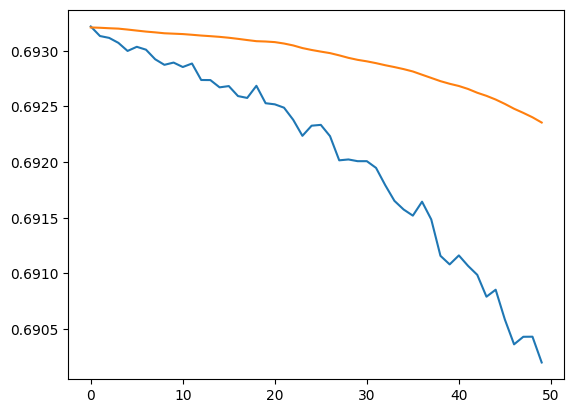

In [9]:
plt.plot(history['loss'])
plt.plot(history['val_loss'])
plt.show()

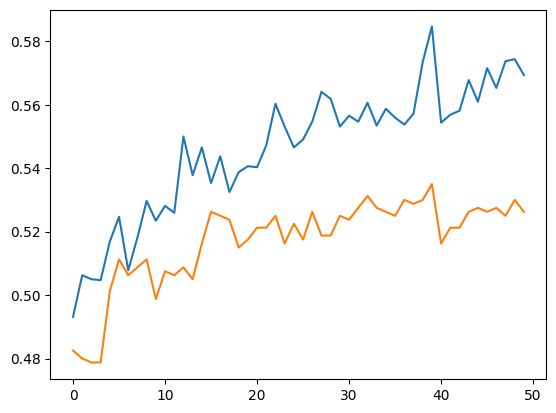

In [10]:
plt.plot(history['accuracy'])
plt.plot(history['val_accuracy'])
plt.show()

In [11]:
predictions = model.predict(x_test,verbose=0)

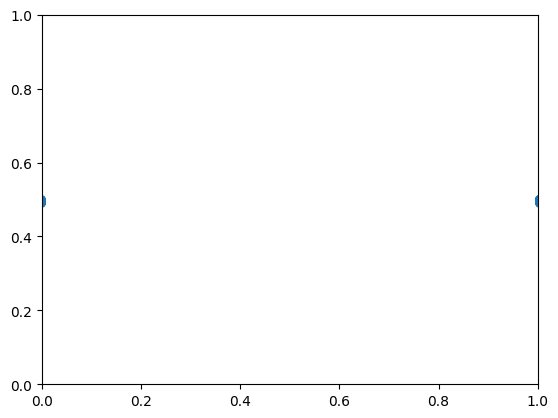

In [12]:
plt.scatter(y_test,predictions, marker='.')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

In [13]:
matrix = confusion_matrix(y_test, (predictions > .5).astype(int))
matrix

array([[471,  40],
       [401,  88]])

In [14]:
matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

array([[0.92172211, 0.07827789],
       [0.8200409 , 0.1799591 ]])